## This notebook contains results for various lattice configurations with a reduced RF gradient of 1.25 MV/m (5% nominal).

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)

from functions.read_g4bl_data import readTraceData, readDetData
from functions.set_plot_settings import setPlotSettings

setPlotSettings(font=True)

### w/ reference particle

given initial conditions corresponding to matched reference orbit for optics-only case

In [2]:
data = readTraceData('AllTracks_grad1pt25.txt')

In [3]:
# remove last period (for fringe-field mitigation)
# 2 periods HFOFO + 1 at start + 1 at end
period_len = 4200
data = data[data['z'] < 500+period_len*2]

In [4]:
data = data.sort_values('z')

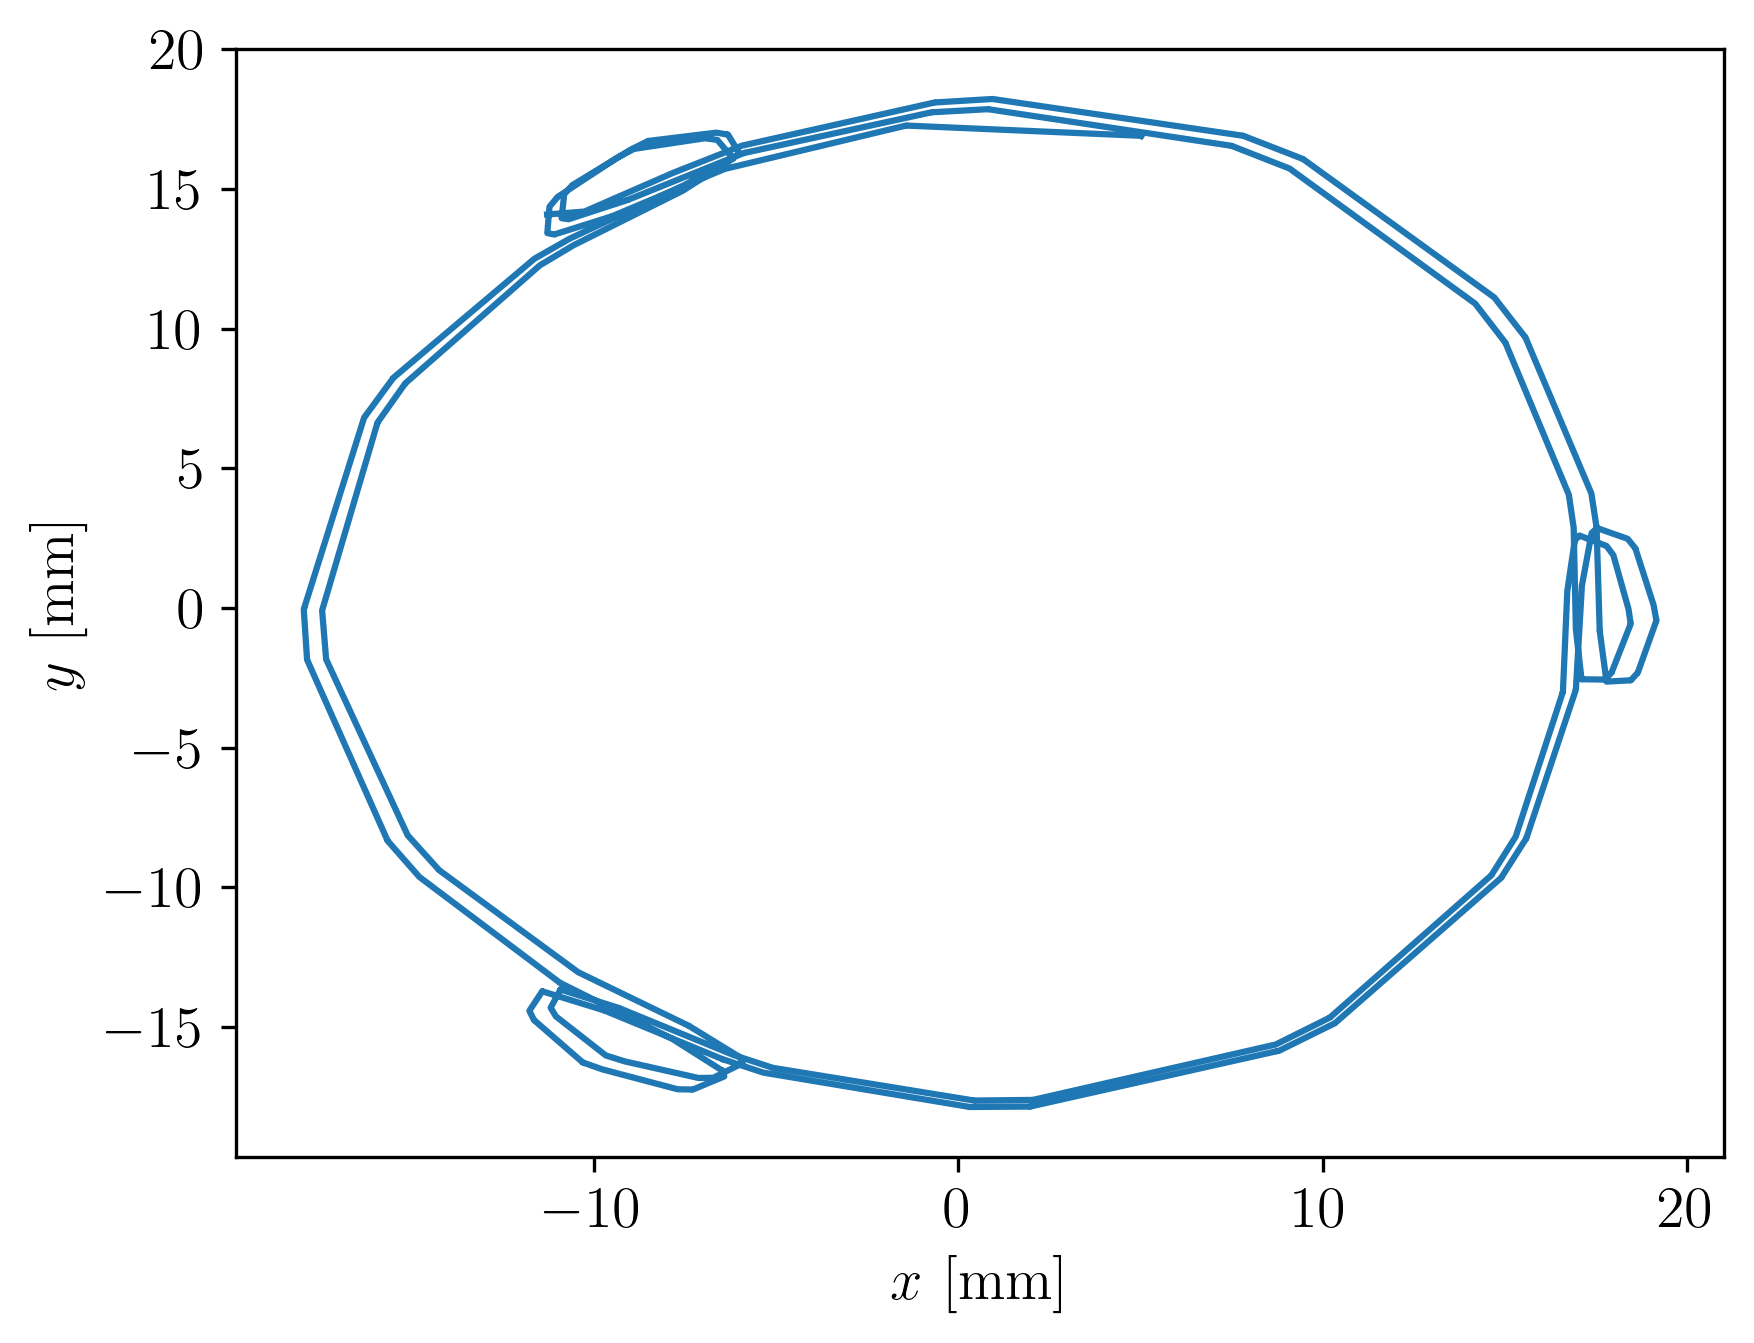

In [5]:
plt.plot(data['x'], data['y'])
plt.xlabel('$x$ [mm]')
plt.ylabel('$y$ [mm]');

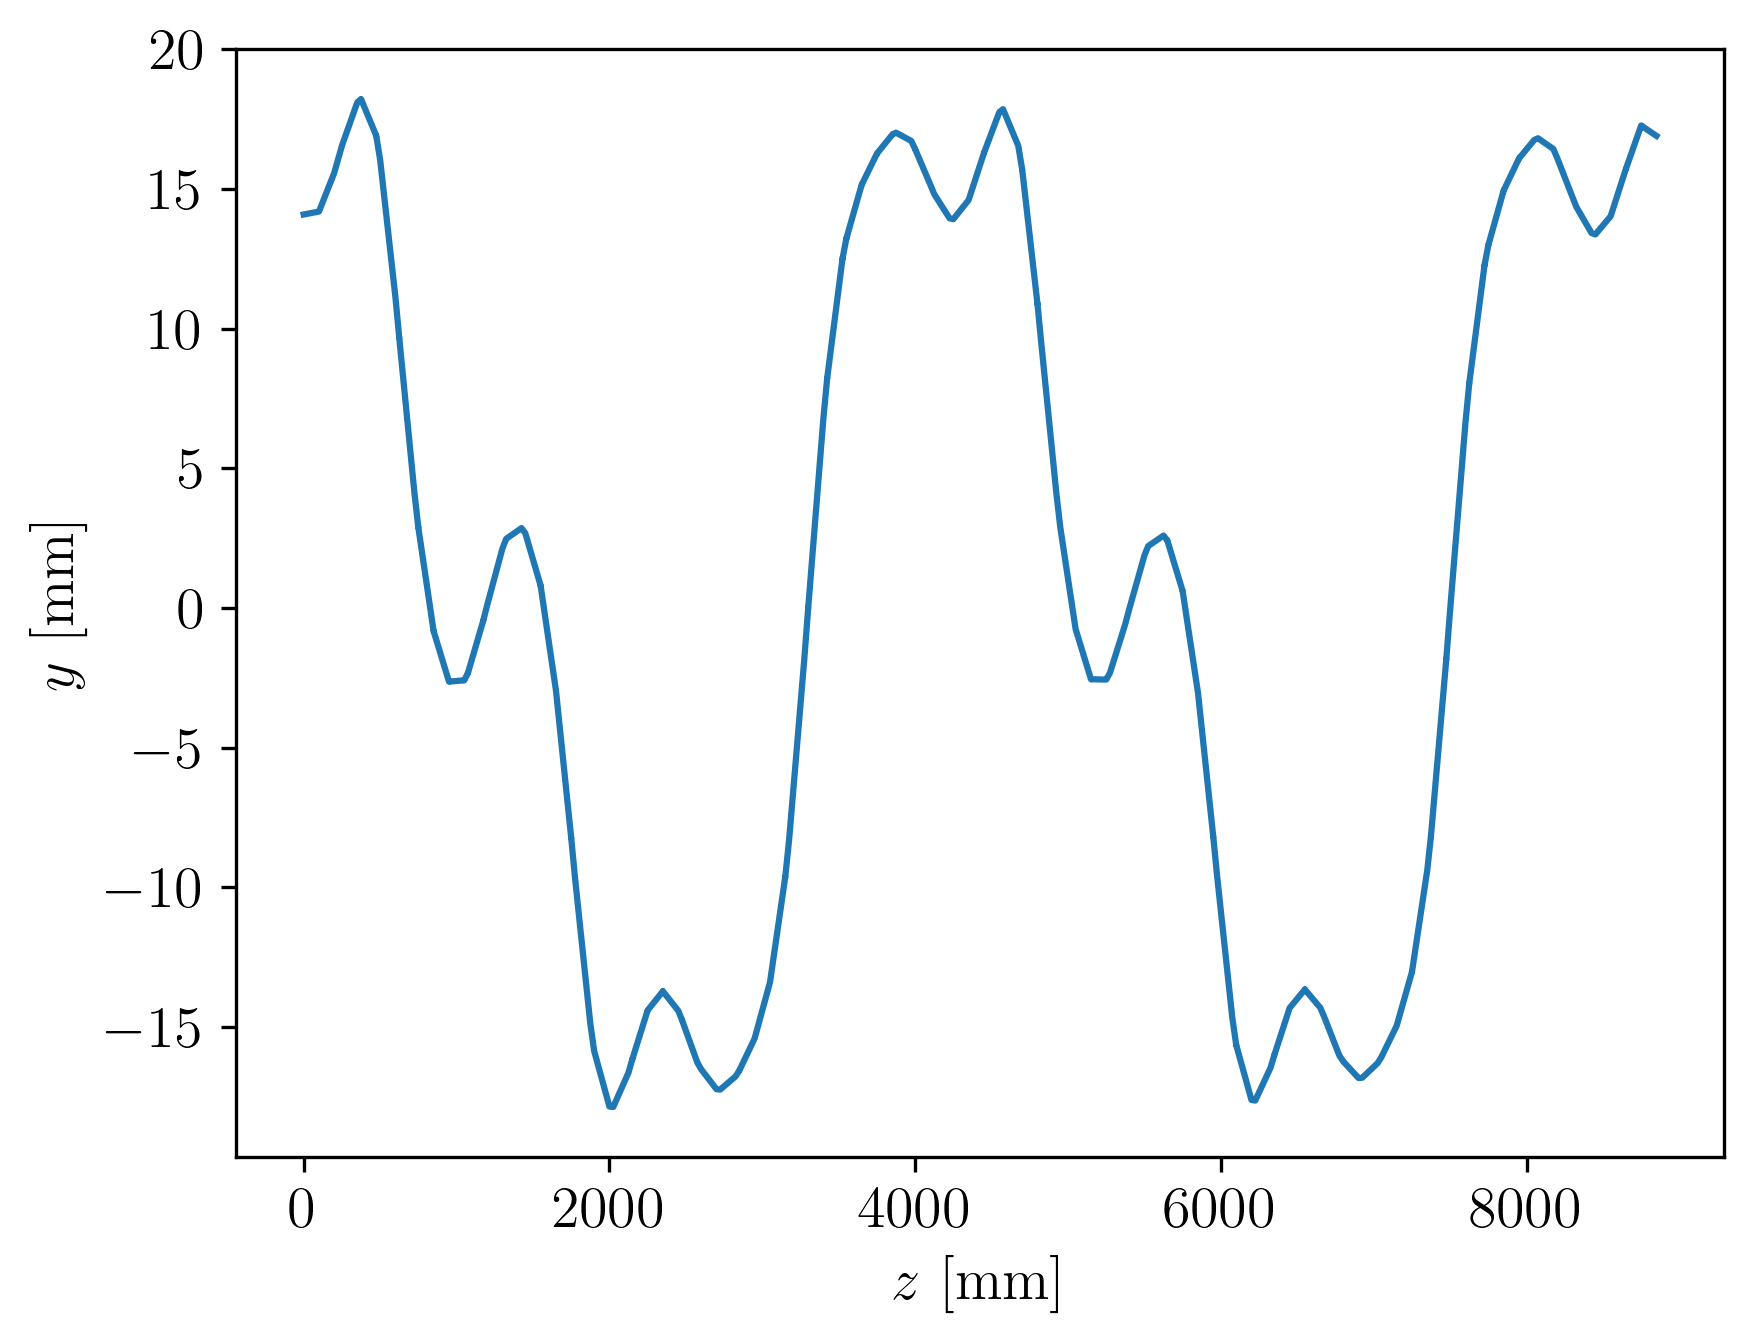

In [6]:
plt.plot(data['z'], data['y'])
plt.xlabel('$z$ [mm]')
plt.ylabel('$y$ [mm]');

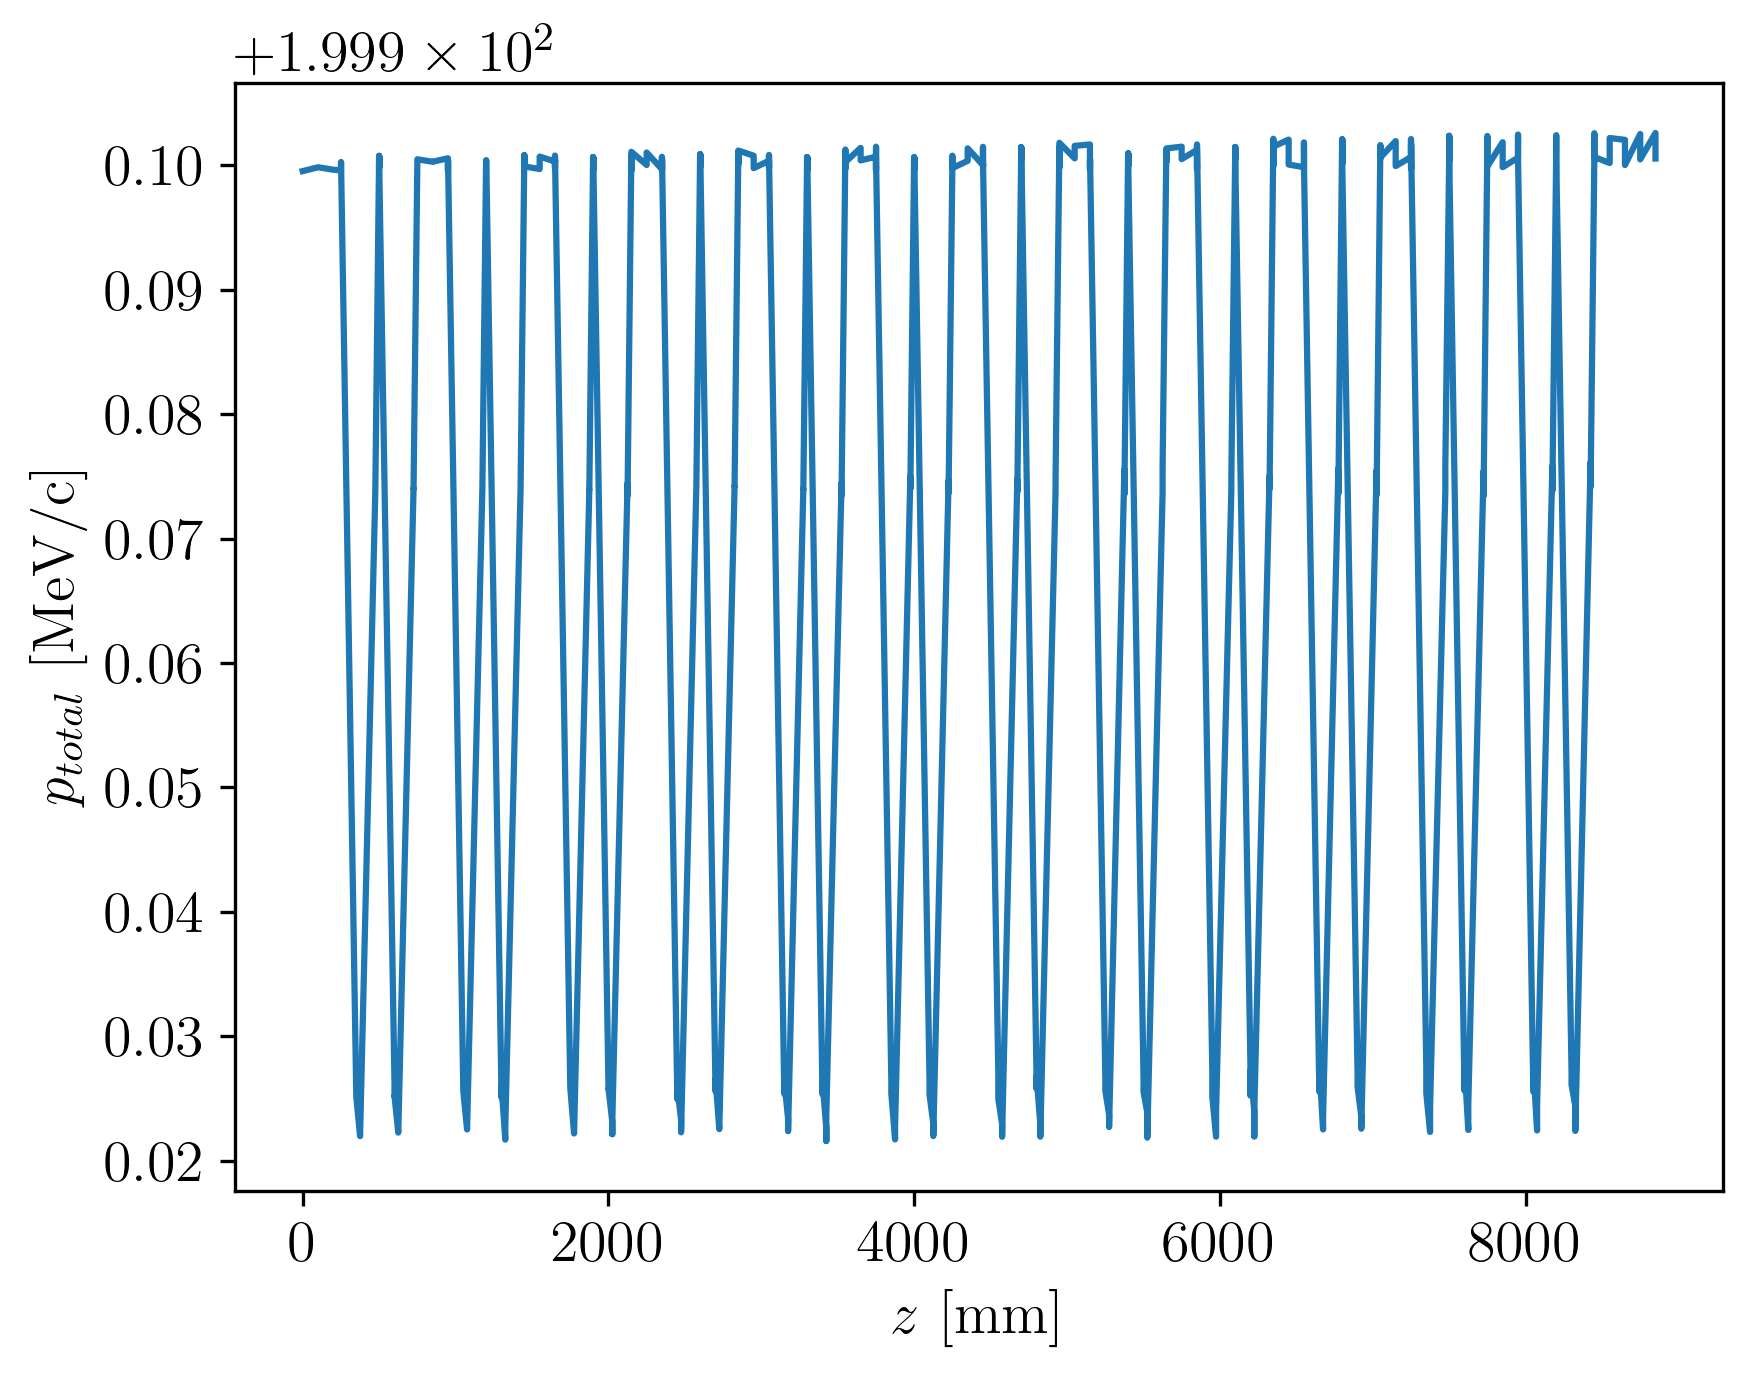

In [7]:
plt.plot(data['z'], data['ptotal'])
plt.xlabel('$z$ [mm]')
plt.ylabel('$p_{total}$ [MeV/c]');

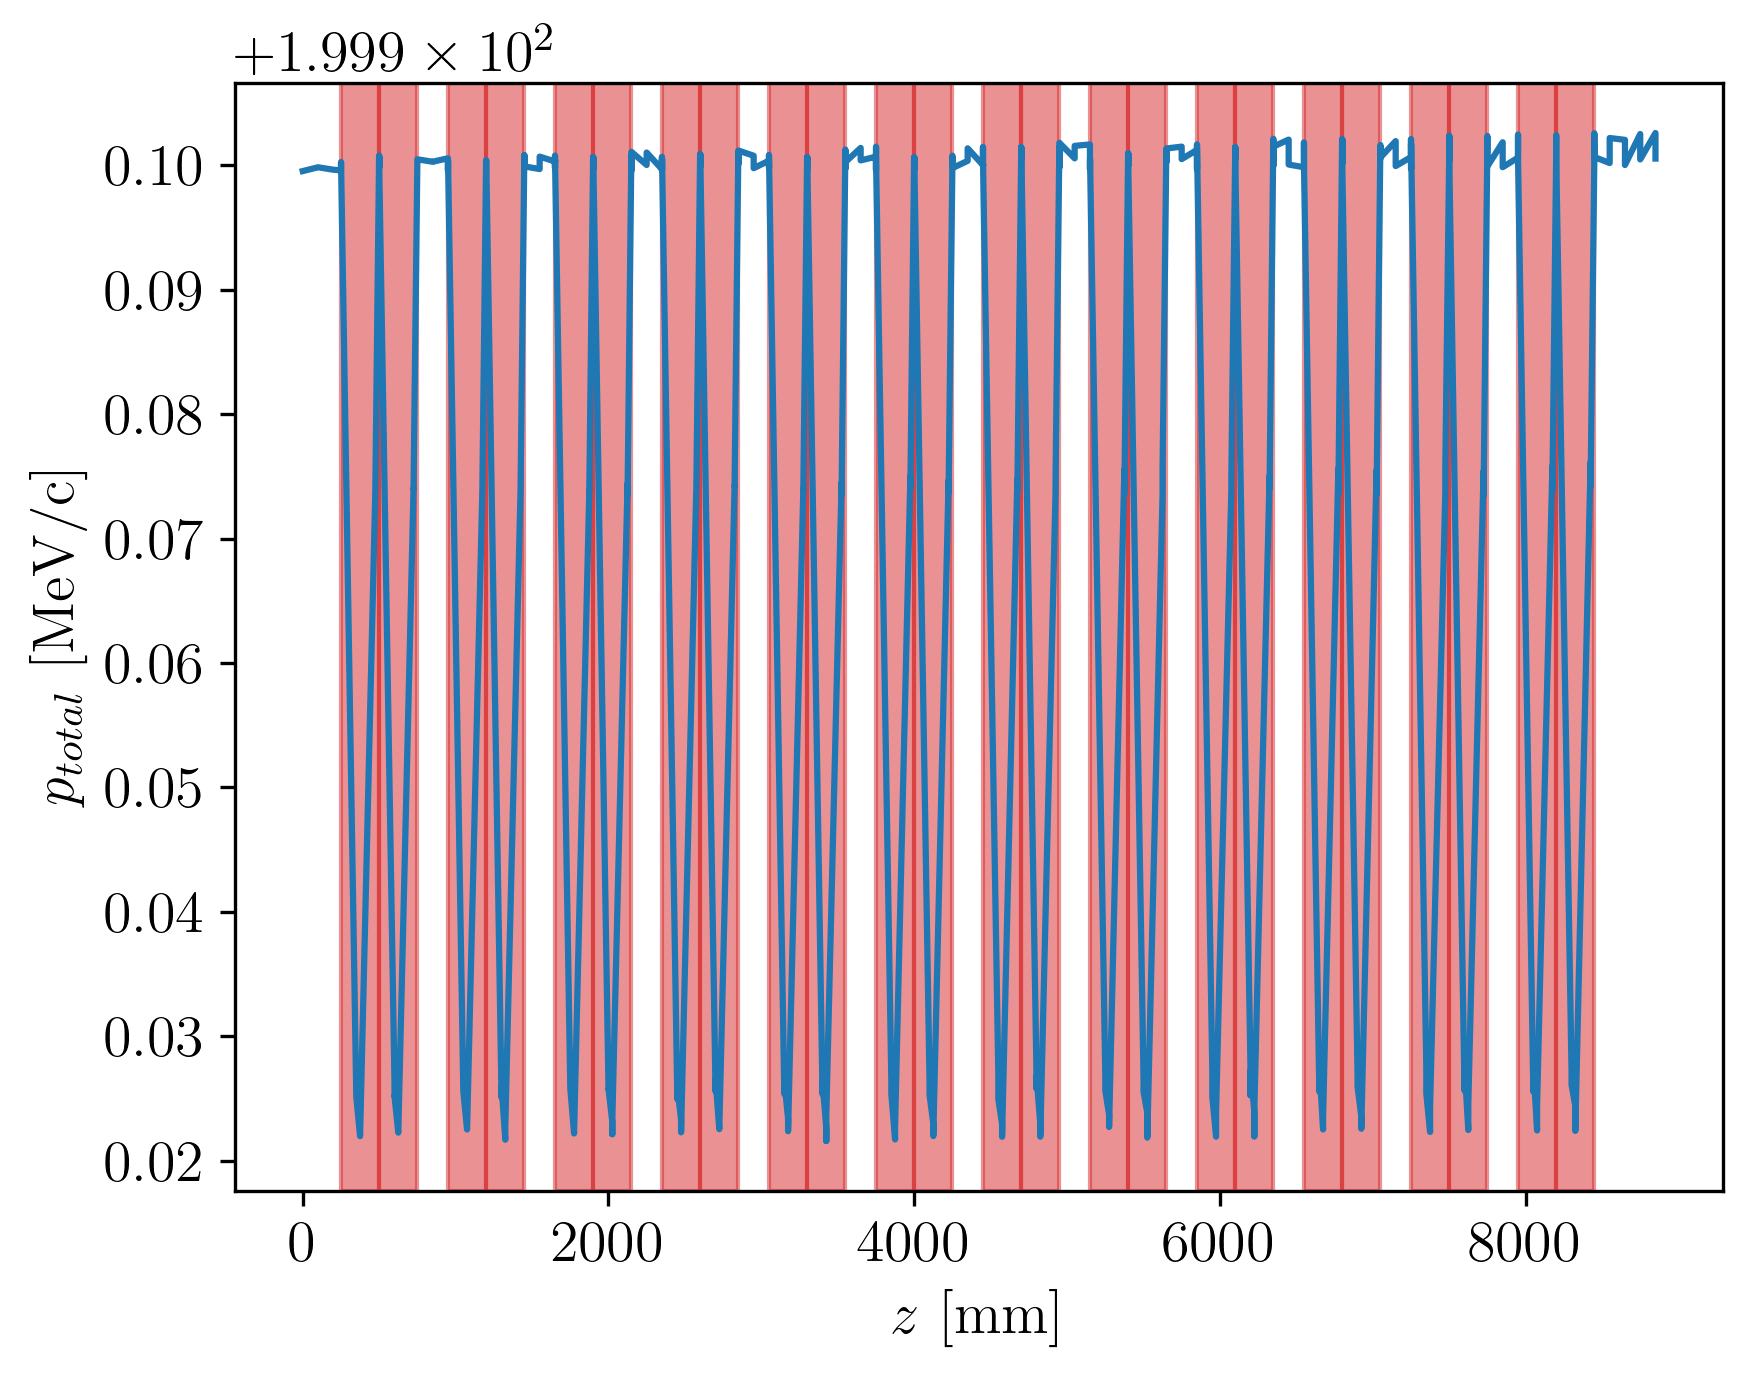

In [8]:
plt.plot(data['z'], data['ptotal'])
plt.xlabel('$z$ [mm]')
plt.ylabel('$p_{total}$ [MeV/c]')
# plt.xlim(500,4700)
rf_len = 250
space = period_len/6
for i in range(12):
    z1 = 500-rf_len/2+space*i
    z2 = 500+rf_len/2+space*i
    plt.axvspan(xmin=z1-rf_len/2,xmax=z1+rf_len/2,color='tab:red',alpha=0.5,zorder=-0.5)
    plt.axvspan(xmin=z2-rf_len/2,xmax=z2+rf_len/2,color='tab:red',alpha=0.5,zorder=-0.5)

### w/ beam

In [ ]:
data_beam = readDetData('zntuple_grad1pt25.txt')

In [221]:
# for ID in np.unique(data_beam['EventID']):
#     plt.plot(data_beam[data_beam['EventID']==ID]['x'], data_beam[data_beam['EventID']==ID]['y'],lw=0.5)
#     plt.xlabel('$x$ [mm]')
#     plt.ylabel('$y$ [mm]');

In [222]:
# for ID in np.unique(data_beam['EventID']):
#     plt.figure()
#     plt.plot(data_beam[data_beam['EventID']==ID]['x'], data_beam[data_beam['EventID']==ID]['y'],lw=0.5)
#     plt.scatter(data_beam[data_beam['EventID']==ID][data_beam['z']==0]['x'], data_beam[data_beam['EventID']==ID][data_beam['z']==0]['y'],color='tab:red');
#     plt.title(f'EventID {int(ID)}')

In [223]:
IDs = np.unique(data_beam['EventID'])
diffs = []
for ID in IDs:
    x0 = data_beam[data_beam['EventID']==ID][data_beam['z']==0]['x'].values[0]
    xf = data_beam[data_beam['EventID']==ID][data_beam['z']==4200]['x'].values[0]
    y0 = data_beam[data_beam['EventID']==ID][data_beam['z']==0]['y'].values[0]
    yf = data_beam[data_beam['EventID']==ID][data_beam['z']==4200]['y'].values[0]
    diff = np.sqrt((xf-x0)**2+(yf-y0)**2)
    diffs.append(diff)

/var/folders/d1/72_2xzds6lz0krc7zdw_94_m0000gp/T/ipykernel_47752/139314352.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x0 = data_beam[data_beam['EventID']==ID][data_beam['z']==0]['x'].values[0]
/var/folders/d1/72_2xzds6lz0krc7zdw_94_m0000gp/T/ipykernel_47752/139314352.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  xf = data_beam[data_beam['EventID']==ID][data_beam['z']==4200]['x'].values[0]
/var/folders/d1/72_2xzds6lz0krc7zdw_94_m0000gp/T/ipykernel_47752/139314352.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  y0 = data_beam[data_beam['EventID']==ID][data_beam['z']==0]['y'].values[0]
/var/folders/d1/72_2xzds6lz0krc7zdw_94_m0000gp/T/ipykernel_47752/139314352.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  yf = data_beam[data_beam['EventID']==ID][data_beam['z']==4200]['y'].values[0]
/var/folders/d1/72_2xzds6lz0krc7zdw_94_m0000gp/T/ipykernel

In [224]:
solID = int(IDs[np.where(diffs==np.min(diffs))][0])
print(solID)

1648


In [225]:
init = data_beam[data_beam['EventID']==solID][data_beam['z']==0];
print(f"x : {init['x'].values}")
print(f"y : {init['y'].values}")
print(f"xp : {init['xp'].values}")
print(f"yp : {init['yp'].values}")

x : [-11.3758]
y : [14.0462]
xp : [0.00339318]
yp : [-0.00627766]


/var/folders/d1/72_2xzds6lz0krc7zdw_94_m0000gp/T/ipykernel_47752/2738710305.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  init = data_beam[data_beam['EventID']==solID][data_beam['z']==0];


/var/folders/d1/72_2xzds6lz0krc7zdw_94_m0000gp/T/ipykernel_47752/398499464.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plt.scatter(data_beam[data_beam['EventID']==solID][data_beam['z']==0]['x'], data_beam[data_beam['EventID']==solID][data_beam['z']==0]['y'],color='tab:red',s=2);
/var/folders/d1/72_2xzds6lz0krc7zdw_94_m0000gp/T/ipykernel_47752/398499464.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plt.scatter(data_beam[data_beam['EventID']==solID][data_beam['z']==0]['x'], data_beam[data_beam['EventID']==solID][data_beam['z']==0]['y'],color='tab:red',s=2);


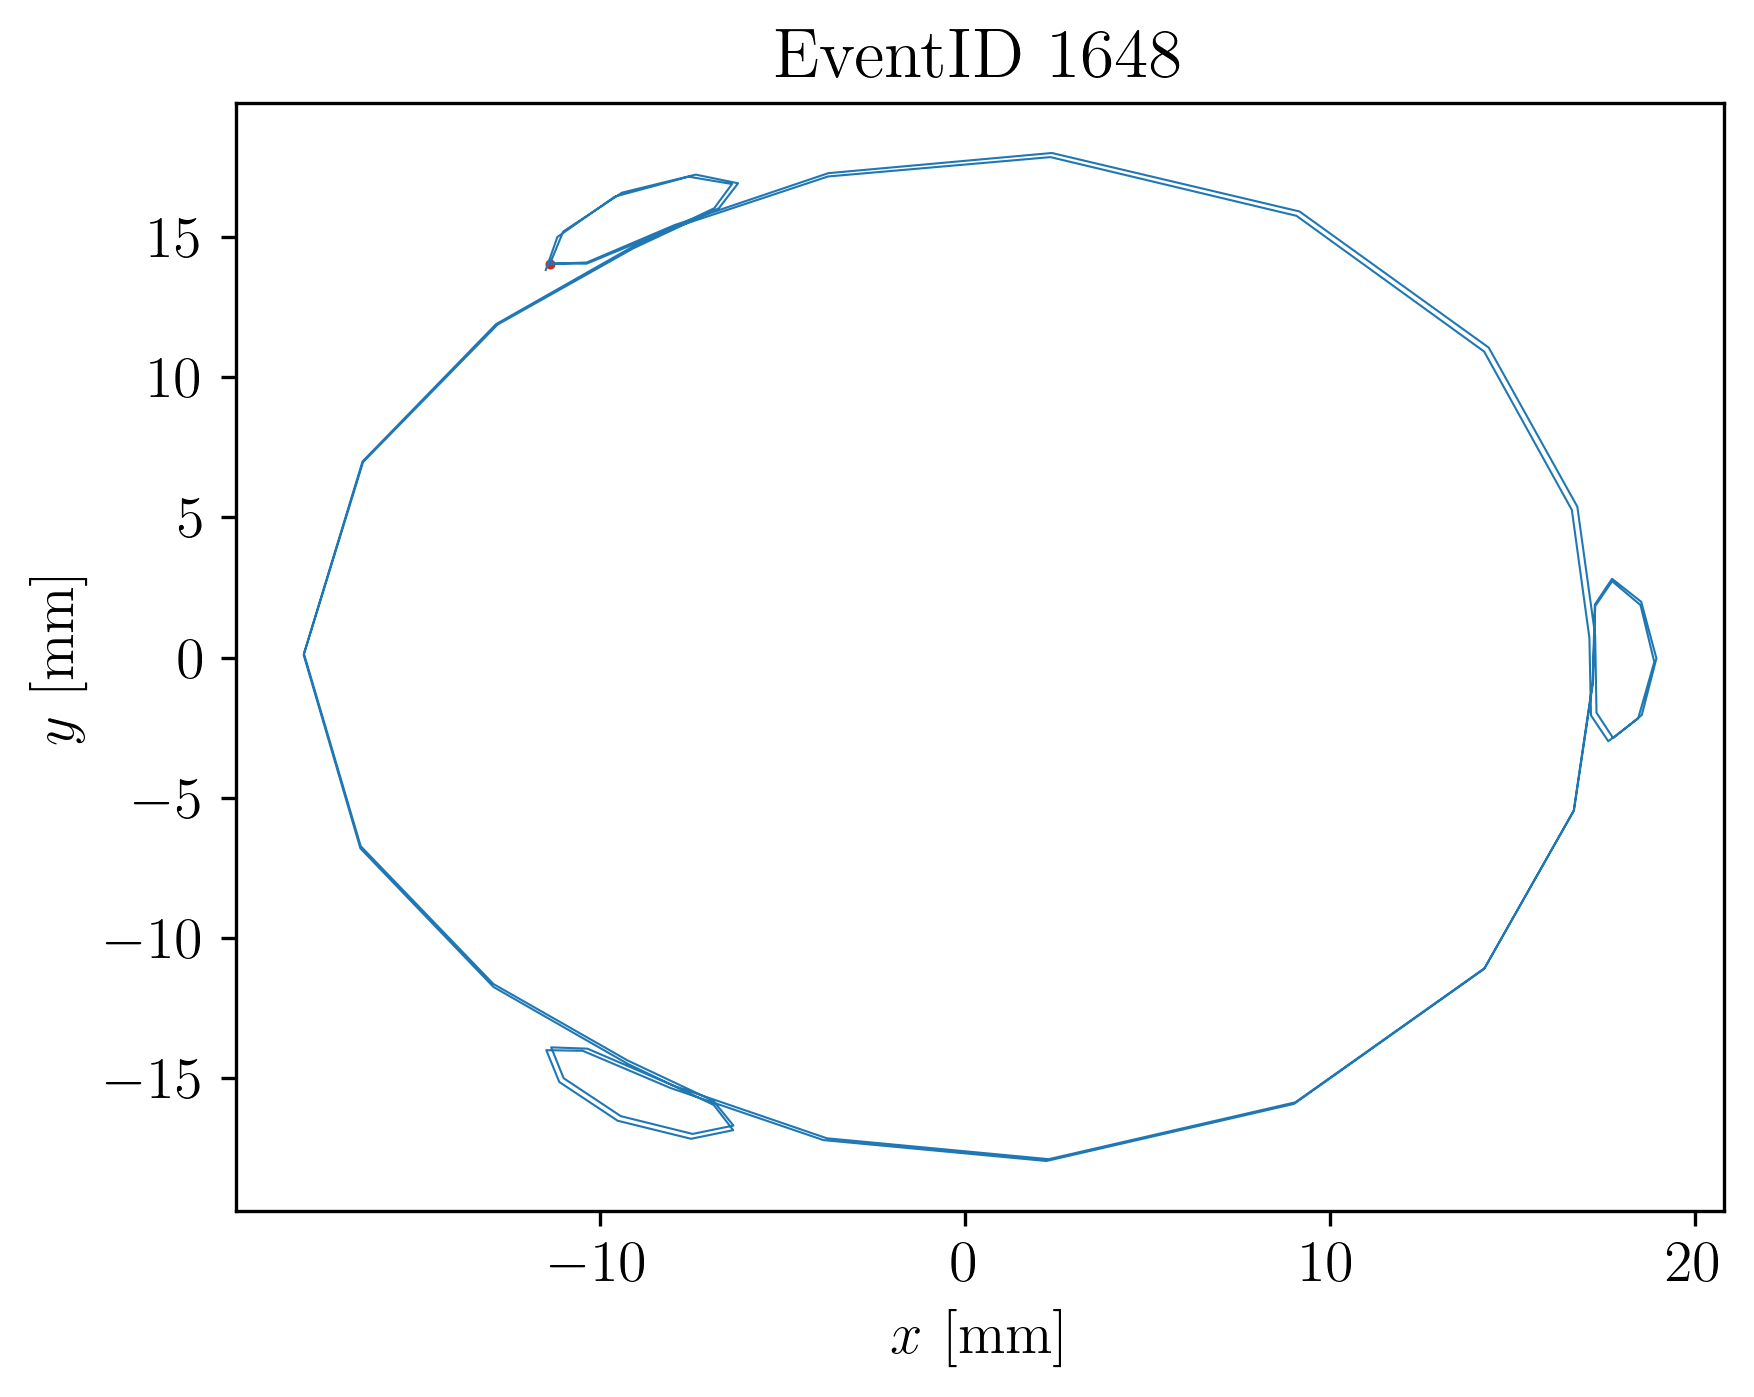

In [226]:
plt.figure()
plt.plot(data_beam[data_beam['EventID']==solID]['x'], data_beam[data_beam['EventID']==solID]['y'],lw=0.5)
plt.scatter(data_beam[data_beam['EventID']==solID][data_beam['z']==0]['x'], data_beam[data_beam['EventID']==solID][data_beam['z']==0]['y'],color='tab:red',s=2);
plt.title(f'EventID {int(solID)}')
plt.xlabel('$x$ [mm]')
plt.ylabel('$y$ [mm]');

param X=-11.3752
param Y=14.0458
param Xp=0.00336102
param Yp=-0.00629481

beam gaussian particle=mu+ nEvents=2000 \
beamZ=0.0 beamX=$X beamY=$Y beamXp=$Xp beamYp=$Yp \ 
sigmaX=0.001 sigmaY=0.001 sigmaXp=0.0001 sigmaYp=0.0001 \ 
meanMomentum=$p sigmaP=0.0 meanT=0.0 sigmaT=0.0

### for all 30 periods

In [ ]:
data_beam = readDetData('zntuple_grad1pt25_30periods.txt')

In [246]:
IDs = np.unique(data_beam['EventID'])
diffs = []
for ID in IDs:
    x0 = data_beam[data_beam['EventID']==ID][data_beam['z']==0]['x'].values[0]
    xf = data_beam[data_beam['EventID']==ID][data_beam['z']==period_len*30]['x'].values[0]
    y0 = data_beam[data_beam['EventID']==ID][data_beam['z']==0]['y'].values[0]
    yf = data_beam[data_beam['EventID']==ID][data_beam['z']==period_len*30]['y'].values[0]
    diff = np.sqrt((xf-x0)**2+(yf-y0)**2)
    diffs.append(diff)

/var/folders/d1/72_2xzds6lz0krc7zdw_94_m0000gp/T/ipykernel_47752/2418712967.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x0 = data_beam[data_beam['EventID']==ID][data_beam['z']==0]['x'].values[0]
/var/folders/d1/72_2xzds6lz0krc7zdw_94_m0000gp/T/ipykernel_47752/2418712967.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  xf = data_beam[data_beam['EventID']==ID][data_beam['z']==period_len*30]['x'].values[0]
/var/folders/d1/72_2xzds6lz0krc7zdw_94_m0000gp/T/ipykernel_47752/2418712967.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  y0 = data_beam[data_beam['EventID']==ID][data_beam['z']==0]['y'].values[0]
/var/folders/d1/72_2xzds6lz0krc7zdw_94_m0000gp/T/ipykernel_47752/2418712967.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  yf = data_beam[data_beam['EventID']==ID][data_beam['z']==period_len*30]['y'].values[0]
/var/folders/d1/72_2xzds6lz0krc7zdw_

In [247]:
solID = int(IDs[np.where(diffs==np.min(diffs))][0])
print(solID)

1930


In [248]:
init = data_beam[data_beam['EventID']==solID][data_beam['z']==0];
print(f"x : {init['x'].values}")
print(f"y : {init['y'].values}")
print(f"xp : {init['xp'].values}")
print(f"yp : {init['yp'].values}")

x : [-11.3606]
y : [14.0513]
xp : [0.00361177]
yp : [-0.00623106]


/var/folders/d1/72_2xzds6lz0krc7zdw_94_m0000gp/T/ipykernel_47752/2738710305.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  init = data_beam[data_beam['EventID']==solID][data_beam['z']==0];


/var/folders/d1/72_2xzds6lz0krc7zdw_94_m0000gp/T/ipykernel_47752/398499464.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plt.scatter(data_beam[data_beam['EventID']==solID][data_beam['z']==0]['x'], data_beam[data_beam['EventID']==solID][data_beam['z']==0]['y'],color='tab:red',s=2);
/var/folders/d1/72_2xzds6lz0krc7zdw_94_m0000gp/T/ipykernel_47752/398499464.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plt.scatter(data_beam[data_beam['EventID']==solID][data_beam['z']==0]['x'], data_beam[data_beam['EventID']==solID][data_beam['z']==0]['y'],color='tab:red',s=2);


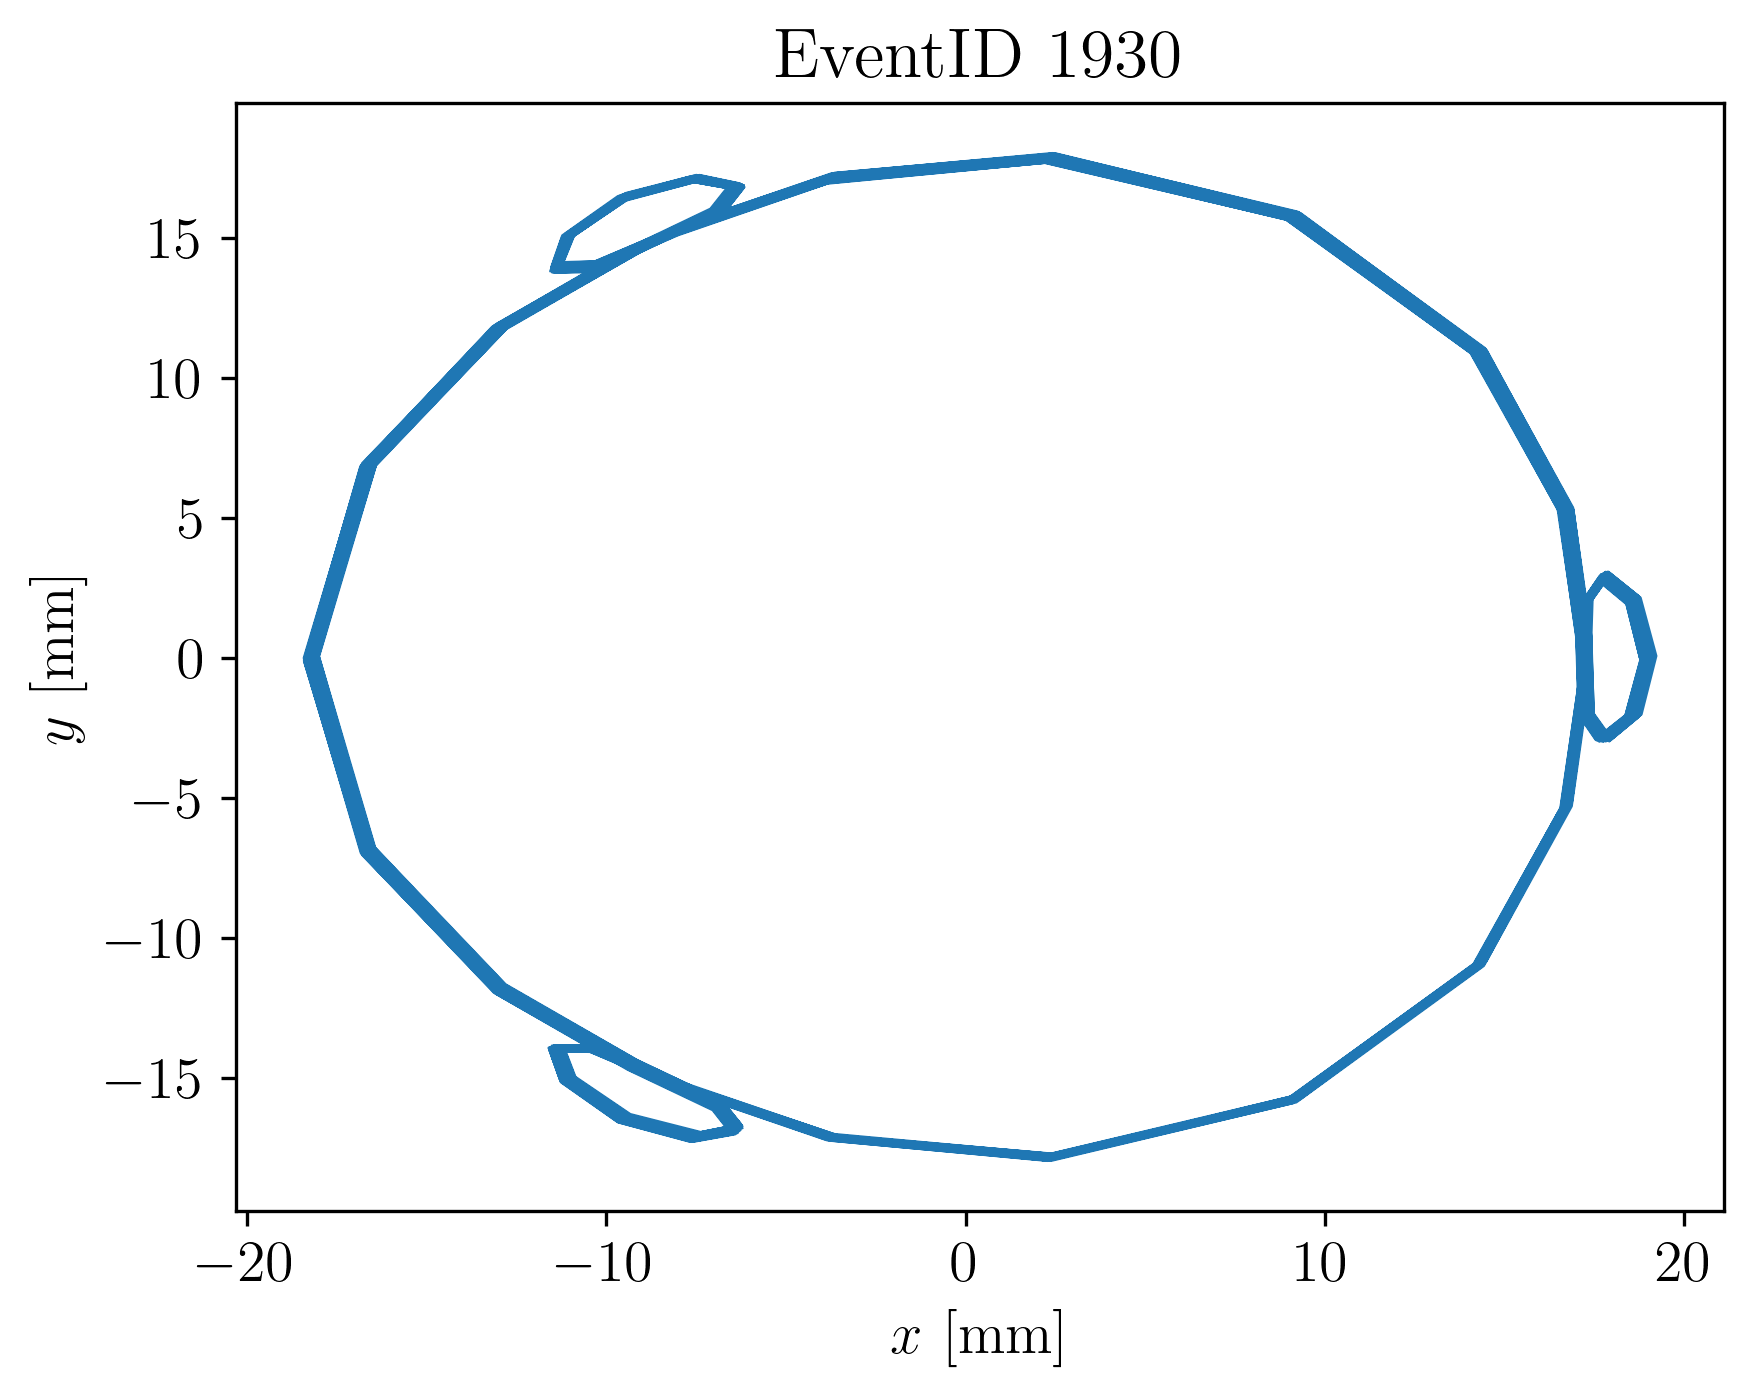

In [249]:
plt.figure()
plt.plot(data_beam[data_beam['EventID']==solID]['x'], data_beam[data_beam['EventID']==solID]['y'],lw=0.5)
plt.scatter(data_beam[data_beam['EventID']==solID][data_beam['z']==0]['x'], data_beam[data_beam['EventID']==solID][data_beam['z']==0]['y'],color='tab:red',s=2);
plt.title(f'EventID {int(solID)}')
plt.xlabel('$x$ [mm]')
plt.ylabel('$y$ [mm]');

/var/folders/d1/72_2xzds6lz0krc7zdw_94_m0000gp/T/ipykernel_47752/4121602141.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plt.scatter(data_beam[data_beam['EventID']==42][data_beam['z']==0]['x'], data_beam[data_beam['EventID']==42][data_beam['z']==0]['y'],color='tab:red',s=2);
/var/folders/d1/72_2xzds6lz0krc7zdw_94_m0000gp/T/ipykernel_47752/4121602141.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plt.scatter(data_beam[data_beam['EventID']==42][data_beam['z']==0]['x'], data_beam[data_beam['EventID']==42][data_beam['z']==0]['y'],color='tab:red',s=2);


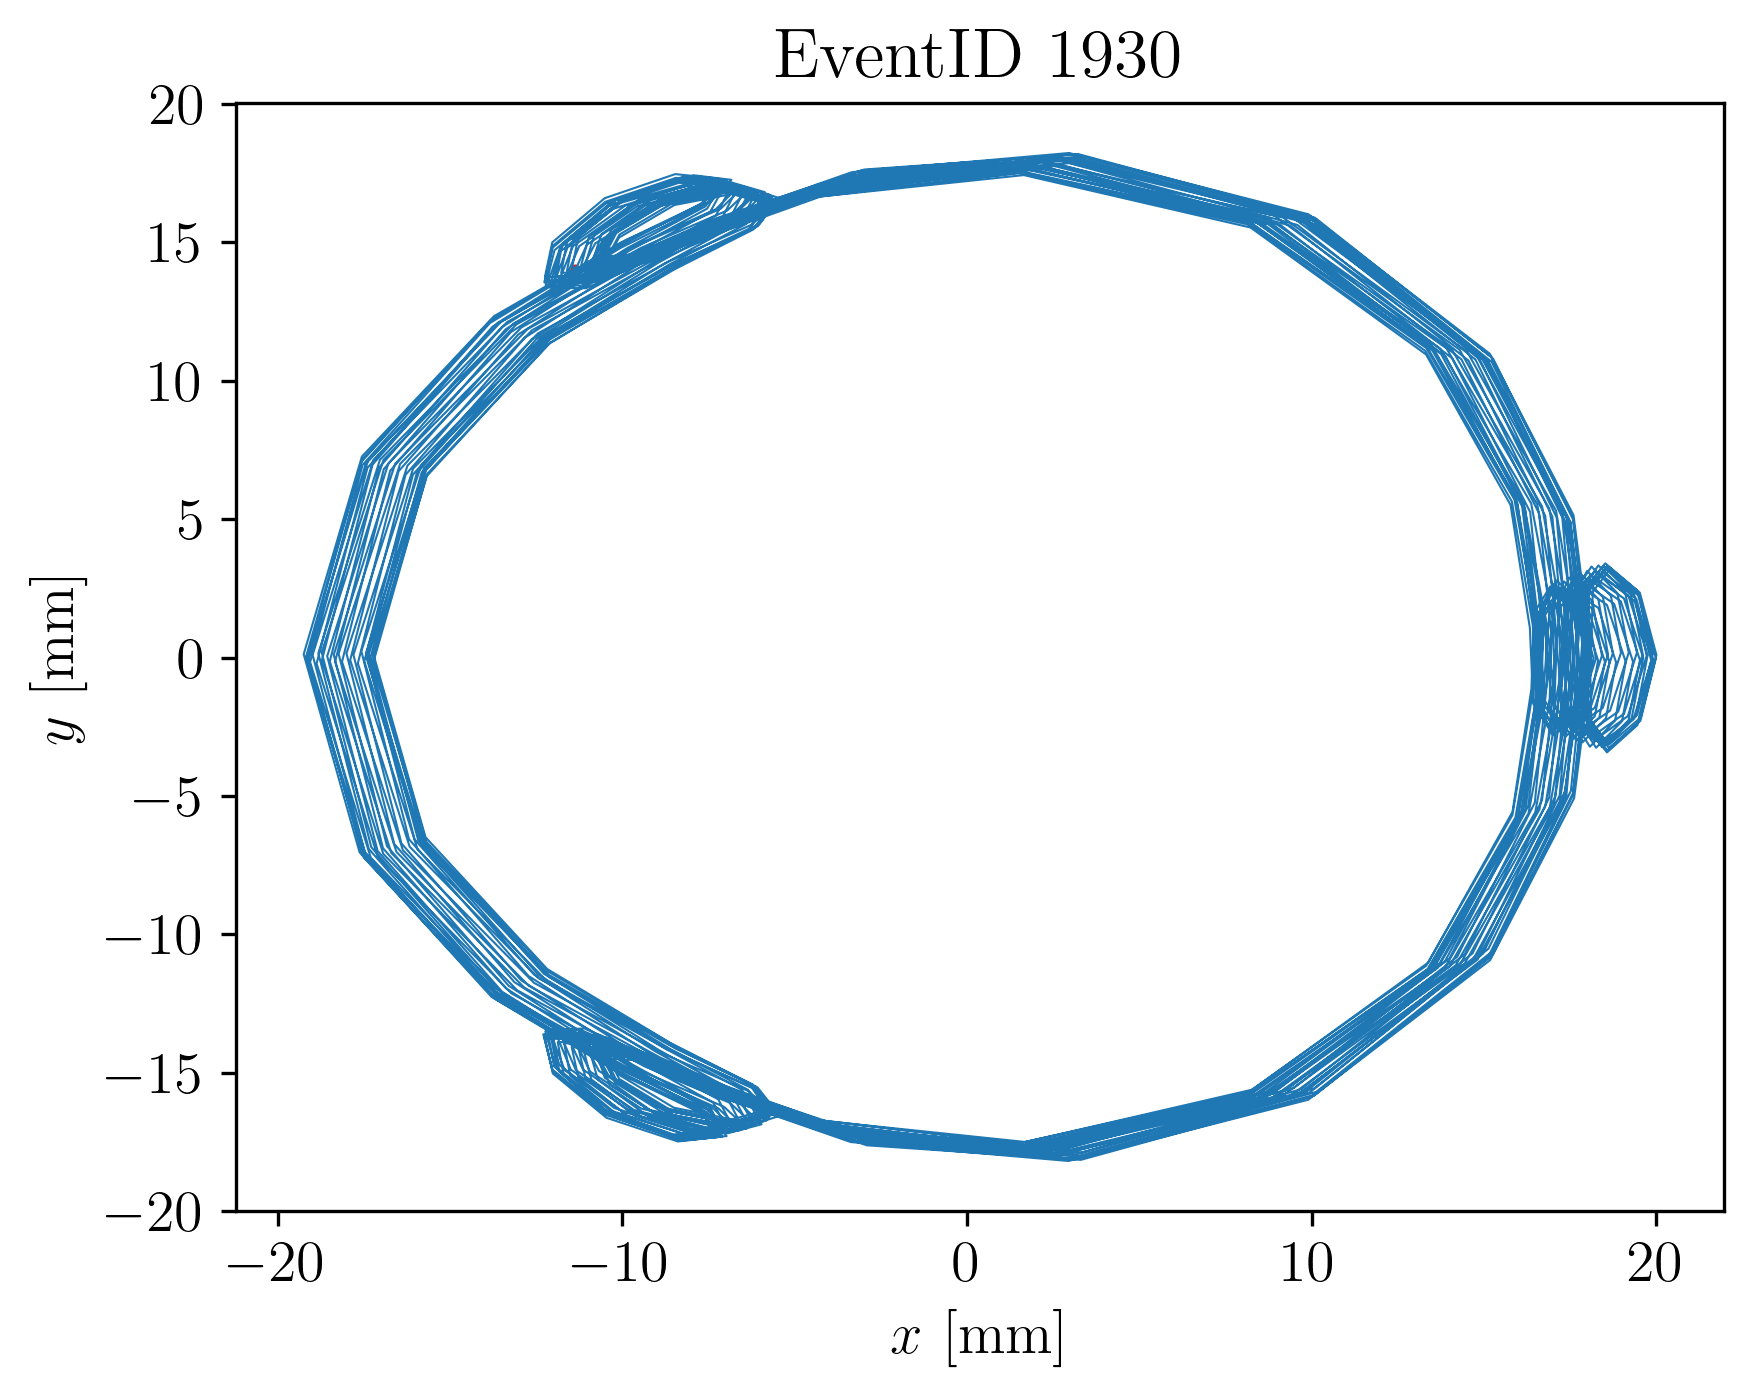

In [250]:
plt.figure()
plt.plot(data_beam[data_beam['EventID']==42]['x'], data_beam[data_beam['EventID']==42]['y'],lw=0.5)
plt.scatter(data_beam[data_beam['EventID']==42][data_beam['z']==0]['x'], data_beam[data_beam['EventID']==42][data_beam['z']==0]['y'],color='tab:red',s=2);
plt.title(f'EventID {int(solID)}')
plt.xlabel('$x$ [mm]')
plt.ylabel('$y$ [mm]');